# Generative Model — Conv-VAE on CIFAR-10 (vehicles subset)

**Project:** Generative AI Applications
**Notebook:** `generative_model.ipynb`
**Framework:** PyTorch (CPU)

## 1. Task Definition and Model Choice

This notebook implements a **convolutional Variational Autoencoder (VAE)** trained
on a two-class subset of **CIFAR-10** consisting of the `automobile` and `truck`
classes (10,000 RGB 32×32 images total). The generative task is **unconditional
image generation of vehicle photographs** — given samples drawn from the VAE's
prior, the decoder produces novel 32×32 RGB images that resemble the training
distribution.

A VAE is appropriate for this task because (a) it provides an explicit latent
representation that supports sampling, reconstruction, and interpolation, all of
which are useful for evaluation, and (b) its training objective (the
evidence-lower-bound, or ELBO) is stable and well-understood, making it a sound
choice for a CPU-only training budget where adversarial-network instability
would dominate the experiment.

**Why a CIFAR-10 subset rather than the full dataset:** a small VAE trained for a
modest number of CPU epochs cannot model the diversity of all ten CIFAR-10
classes well; restricting the data to two visually-related classes (vehicles)
gives the model a single, coherent visual concept to learn and produces
qualitatively interpretable samples.


## 2. Environment and Imports

In [1]:
import os, sys, math, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

print('python  :', sys.version.split()[0])
print('numpy   :', np.__version__)
print('pandas  :', pd.__version__)
print('torch   :', torch.__version__)
print('tv      :', torchvision.__version__)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device  :', device)


python  : 3.12.10
numpy   : 2.4.4
pandas  : 3.0.2
torch   : 2.11.0+cpu
tv      : 0.26.0+cpu
device  : cpu


## 3. Data Loading and Inspection

CIFAR-10 is auto-downloaded by `torchvision.datasets.CIFAR10(..., download=True)`.
We keep only the two vehicle classes (`automobile` = 1, `truck` = 9) by index
filtering. Pixels are scaled to `[0, 1]` and kept in that range so the decoder
can use a per-pixel sigmoid output and a Bernoulli/BCE-style reconstruction
loss — a standard formulation for VAEs on bounded-pixel images.

In [2]:
DATA_ROOT = './data'
os.makedirs(DATA_ROOT, exist_ok=True)

# Pixels in [0, 1]; no normalisation, so decoder sigmoid output matches.
tfm = transforms.ToTensor()

train_full = datasets.CIFAR10(DATA_ROOT, train=True,  download=True, transform=tfm)
test_full  = datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tfm)

CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
KEEP = {1, 9}  # automobile, truck

def vehicle_indices(ds):
    return [i for i, t in enumerate(ds.targets) if t in KEEP]

train_idx = vehicle_indices(train_full)
test_idx  = vehicle_indices(test_full)

train_ds = Subset(train_full, train_idx)
test_ds  = Subset(test_full,  test_idx)

print(f'train images: {len(train_ds):,}  | test images: {len(test_ds):,}')
print(f'classes kept : {[CIFAR_CLASSES[i] for i in sorted(KEEP)]}')


0.0%

0.0%

0.1%

0.1%

0.1%

...

100.0%

100.0%

100.0%

C:\Users\dev\sources\udacity\Project 5 - Generative AI Applications\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train images: 10,000  | test images: 2,000
classes kept : ['automobile', 'truck']


In [3]:
# Class balance check
train_labels = [train_full.targets[i] for i in train_idx]
test_labels  = [test_full.targets[i]  for i in test_idx]
balance = pd.DataFrame({
    'split': ['train']*len(train_labels) + ['test']*len(test_labels),
    'class': [CIFAR_CLASSES[t] for t in train_labels + test_labels],
})
print(balance.groupby(['split','class']).size().unstack(fill_value=0))


class  automobile  truck
split                   
test         1000   1000
train        5000   5000


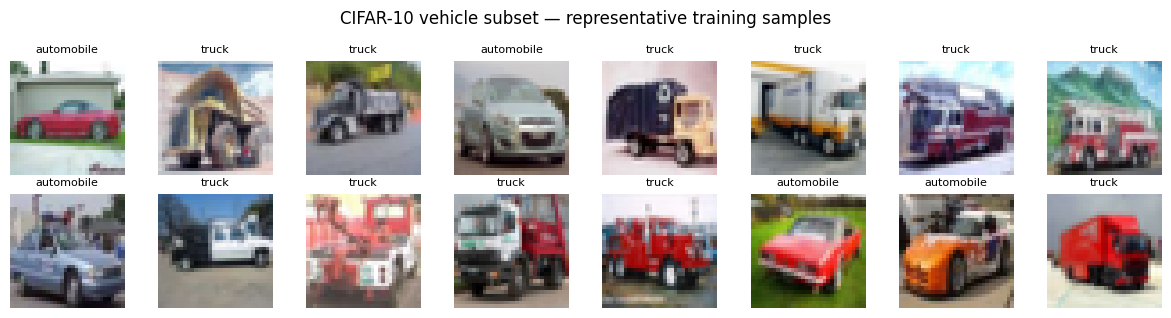

In [4]:
# Display a representative grid of training samples
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, idx in zip(axes.flatten(), random.sample(range(len(train_ds)), 16)):
    img, label = train_ds[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CIFAR_CLASSES[label], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 vehicle subset — representative training samples')
plt.tight_layout(); plt.savefig('fig_samples.png', dpi=120, bbox_inches='tight'); plt.show()


**Preprocessing notes.** Images are 32×32 RGB; pixel values are scaled to
`[0, 1]` only. We deliberately **do not** apply data augmentation (e.g., random
flips), because for a generative model augmentation changes the data
distribution the model is asked to learn, and we want sample quality to reflect
the true CIFAR-10 vehicle distribution.

## 4. Model Architecture

A small **convolutional VAE** with three down-sampling encoder blocks and three
up-sampling decoder blocks. Latent dimension is 64.

* **Encoder:** `3×32×32 → 32×16×16 → 64×8×8 → 128×4×4 → flatten → (μ, log σ²) ∈ ℝ⁶⁴`
* **Reparameterisation:** `z = μ + σ ⊙ ε`, with `ε ~ N(0, I)`
* **Decoder:** `ℝ⁶⁴ → 128×4×4 → 64×8×8 → 32×16×16 → 3×32×32` (sigmoid output)

**Loss.** The standard VAE ELBO, written as a minimisation:

$$
\mathcal{L} = \underbrace{\mathrm{BCE}(\hat{x}, x)}_{\text{reconstruction}}
\;+\;
\beta \cdot \underbrace{\tfrac{1}{2}\sum_i (\mu_i^2 + \sigma_i^2 - \log \sigma_i^2 - 1)}_{D_{KL}(q(z|x)\,\Vert\,\mathcal{N}(0,I))}
$$

`β = 1.0` recovers the original VAE; we keep it at 1.0 here for the standard
formulation. BCE is summed (not averaged) over pixels so its scale matches the
KL term per-image.

In [5]:
LATENT_DIM = 64

class Encoder(nn.Module):
    def __init__(self, z_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,  32, 4, 2, 1), nn.ReLU(inplace=True),   # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(inplace=True),   # 16 -> 8
            nn.Conv2d(64,128, 4, 2, 1), nn.ReLU(inplace=True),   #  8 -> 4
        )
        self.flatten = nn.Flatten()
        self.fc_mu     = nn.Linear(128*4*4, z_dim)
        self.fc_logvar = nn.Linear(128*4*4, z_dim)
    def forward(self, x):
        h = self.flatten(self.conv(x))
        return self.fc_mu(h), self.fc_logvar(h)

class Decoder(nn.Module):
    def __init__(self, z_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(z_dim, 128*4*4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(inplace=True),  # 4  -> 8
            nn.ConvTranspose2d(64,  32, 4, 2, 1), nn.ReLU(inplace=True),  # 8  -> 16
            nn.ConvTranspose2d(32,   3, 4, 2, 1), nn.Sigmoid(),           # 16 -> 32
        )
    def forward(self, z):
        h = self.fc(z).view(-1, 128, 4, 4)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, z_dim=LATENT_DIM):
        super().__init__()
        self.enc = Encoder(z_dim)
        self.dec = Decoder(z_dim)
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparameterise(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar

torch.manual_seed(SEED)
model = VAE().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\ntotal parameters: {n_params:,}')


VAE(
  (enc): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU(inplace=True)
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc_mu): Linear(in_features=2048, out_features=64, bias=True)
    (fc_logvar): Linear(in_features=2048, out_features=64, bias=True)
  )
  (dec): Decoder(
    (fc): Linear(in_features=64, out_features=2048, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Si

## 5. Training

Standard ELBO optimisation with Adam. Reconstruction loss is summed binary
cross-entropy over the 3×32×32 = 3,072 pixel channels per image; the KL term is
the closed-form Gaussian KL.

In [6]:
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    bce = F.binary_cross_entropy(x_hat, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kld, bce, kld

BATCH_SIZE = 128
EPOCHS     = 20
LR         = 1e-3

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

opt = torch.optim.Adam(model.parameters(), lr=LR)

history = []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    sum_loss = sum_bce = sum_kld = 0.0
    n_imgs = 0
    for x, _ in train_loader:
        x = x.to(device)
        opt.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, bce, kld = vae_loss(x_hat, x, mu, logvar)
        loss.backward()
        opt.step()
        bs = x.size(0)
        sum_loss += loss.item(); sum_bce += bce.item(); sum_kld += kld.item()
        n_imgs += bs

    # Validation pass on test split (using it as held-out eval, no test-time training).
    model.eval()
    val_loss = val_bce = val_kld = 0.0; v_imgs = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss, bce, kld = vae_loss(x_hat, x, mu, logvar)
            val_loss += loss.item(); val_bce += bce.item(); val_kld += kld.item()
            v_imgs += x.size(0)

    row = {
        'epoch': epoch,
        'train_loss': sum_loss / n_imgs,
        'train_bce' : sum_bce  / n_imgs,
        'train_kld' : sum_kld  / n_imgs,
        'val_loss'  : val_loss / v_imgs,
        'val_bce'   : val_bce  / v_imgs,
        'val_kld'   : val_kld  / v_imgs,
    }
    history.append(row)
    print(f"epoch {epoch:>2}/{EPOCHS}  "
          f"train ELBO/img = {row['train_loss']:.2f}  "
          f"(bce {row['train_bce']:.2f} + kld {row['train_kld']:.2f})  |  "
          f"val ELBO/img = {row['val_loss']:.2f}")

print(f'\ntotal training time: {time.time()-t0:0.1f} s')
hist_df = pd.DataFrame(history)
hist_df.to_csv('training_history.csv', index=False)
hist_df


epoch  1/20  train ELBO/img = 2020.17  (bce 2008.77 + kld 11.40)  |  val ELBO/img = 1910.62


epoch  2/20  train ELBO/img = 1877.59  (bce 1850.28 + kld 27.31)  |  val ELBO/img = 1869.92


epoch  3/20  train ELBO/img = 1844.77  (bce 1814.91 + kld 29.87)  |  val ELBO/img = 1835.68


epoch  4/20  train ELBO/img = 1826.65  (bce 1795.19 + kld 31.46)  |  val ELBO/img = 1820.33


epoch  5/20  train ELBO/img = 1814.81  (bce 1781.39 + kld 33.42)  |  val ELBO/img = 1812.90


...

epoch 17/20  train ELBO/img = 1773.73  (bce 1728.48 + kld 45.25)  |  val ELBO/img = 1794.30


epoch 18/20  train ELBO/img = 1774.88  (bce 1729.51 + kld 45.37)  |  val ELBO/img = 1774.75


epoch 19/20  train ELBO/img = 1772.22  (bce 1726.47 + kld 45.75)  |  val ELBO/img = 1777.80


epoch 20/20  train ELBO/img = 1771.61  (bce 1725.48 + kld 46.13)  |  val ELBO/img = 1773.14

total training time: 52.0 s


,epoch,train_loss,train_bce,train_kld,val_loss,val_bce,val_kld
0,1,2020.173923,2008.774123,11.399793,1910.624148,1886.142539,24.481613
1,2,1877.586391,1850.275194,27.311200,1869.921102,1839.314578,30.606519
2,3,1844.773921,1814.907996,29.865919,1835.679430,1805.320703,30.358716
3,4,1826.645020,1795.187317,31.457705,1820.325375,1788.114258,32.211112
4,5,1814.806745,1781.389580,33.417166,1812.901047,1778.843016,34.058029
5,6,1803.715521,1767.595621,36.119896,1808.861875,1771.612922,37.248945
6,7,1796.644595,1759.330459,37.314137,1801.042391,1762.591180,38.451212
7,8,1791.907700,1753.403361,38.504333,1789.339656,1751.278820,38.060849
8,9,1786.404076,1746.663579,39.740497,1787.099008,1748.348383,38.750638
9,10,1784.521554,1743.720214,40.801340,1794.390430,1752.598305,41.792121


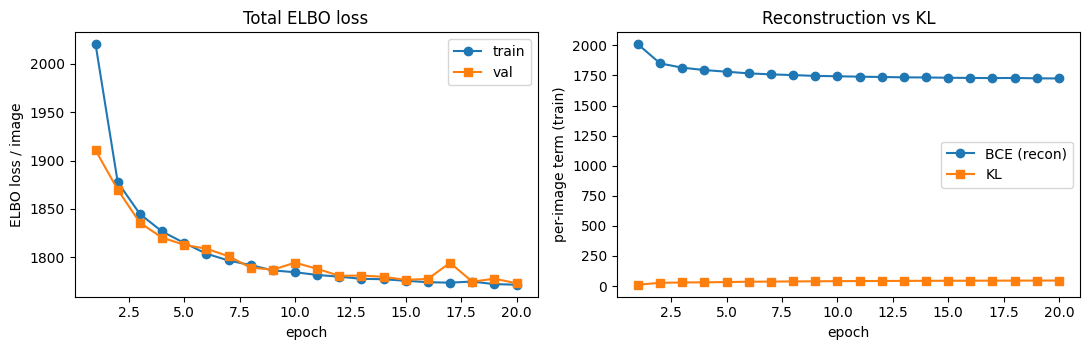

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train', marker='o')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='val',   marker='s')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('ELBO loss / image')
axes[0].set_title('Total ELBO loss'); axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['train_bce'], label='BCE (recon)', marker='o')
axes[1].plot(hist_df['epoch'], hist_df['train_kld'], label='KL',           marker='s')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('per-image term (train)')
axes[1].set_title('Reconstruction vs KL'); axes[1].legend()

plt.tight_layout(); plt.savefig('fig_loss.png', dpi=120, bbox_inches='tight'); plt.show()


## 6. Generation and Evaluation

Three qualitative views of model behavior:

1. **Reconstructions** of held-out test images — does the encoder/decoder pair
   compress and reconstruct unseen vehicles faithfully?
2. **Random samples from the prior** $z \sim \mathcal{N}(0, I)$ — what does
   the learned generative distribution look like when conditioned on nothing?
3. **Latent-space interpolation** between two test images — does linear motion
   in latent space correspond to smooth visual transitions, evidence that the
   latent geometry is meaningful?

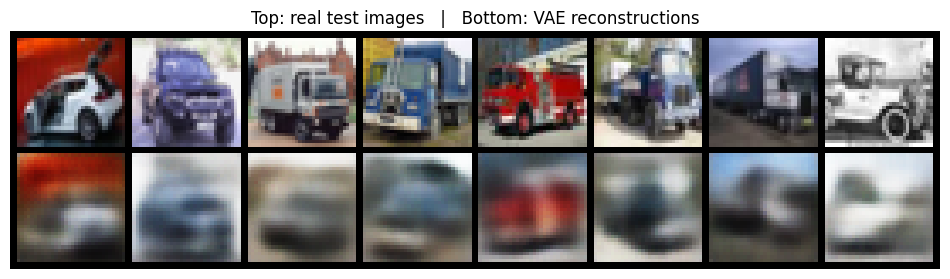

In [8]:
def show_grid(tensor, title, save_as, nrow=8):
    grid = make_grid(tensor.clamp(0,1).cpu(), nrow=nrow, padding=2)
    plt.figure(figsize=(nrow*1.2, (tensor.size(0)//nrow)*1.2 + 0.6))
    plt.imshow(grid.permute(1,2,0).numpy()); plt.axis('off'); plt.title(title)
    plt.tight_layout(); plt.savefig(save_as, dpi=120, bbox_inches='tight'); plt.show()

# (a) Reconstructions
model.eval()
with torch.no_grad():
    x_real, _ = next(iter(test_loader))
    x_real = x_real[:8].to(device)
    x_recon, _, _ = model(x_real)
    pair = torch.cat([x_real, x_recon], dim=0)
show_grid(pair, 'Top: real test images   |   Bottom: VAE reconstructions',
          'fig_reconstructions.png', nrow=8)


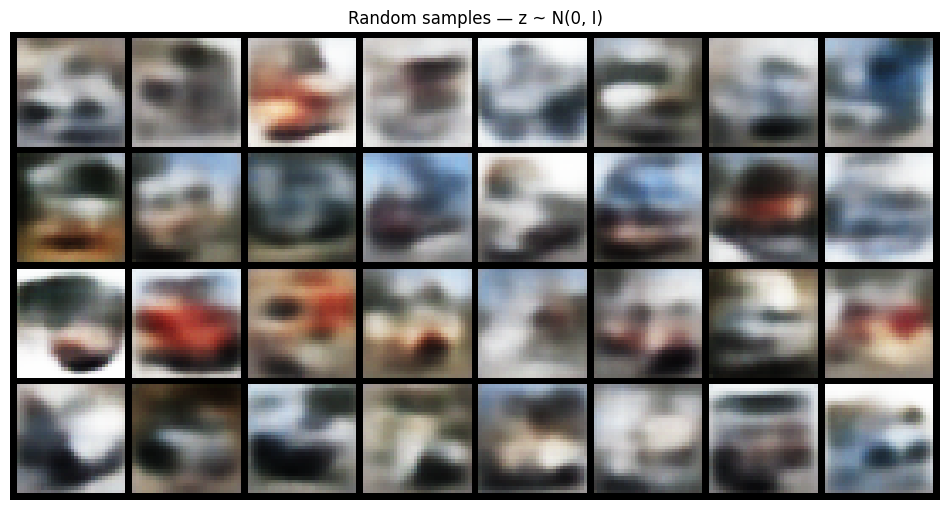

In [9]:
# (b) Random samples from the prior
with torch.no_grad():
    z = torch.randn(32, LATENT_DIM, device=device)
    samples = model.dec(z)
show_grid(samples, 'Random samples — z ~ N(0, I)', 'fig_samples_prior.png', nrow=8)


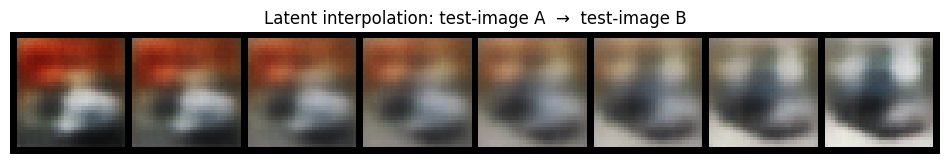

In [10]:
# (c) Latent-space interpolation between two test images
with torch.no_grad():
    x_a, _ = test_ds[0]
    x_b, _ = test_ds[5]
    xs = torch.stack([x_a, x_b]).to(device)
    mu, _ = model.enc(xs)
    alphas = torch.linspace(0, 1, steps=8, device=device).unsqueeze(1)
    z_interp = (1 - alphas) * mu[0:1] + alphas * mu[1:2]
    interp = model.dec(z_interp)
show_grid(interp, 'Latent interpolation: test-image A  →  test-image B',
          'fig_interpolation.png', nrow=8)


### Qualitative observations

* **Reconstructions** preserve dominant low-frequency structure (vehicle silhouette,
  background colour, rough orientation) but lose high-frequency detail —
  paint texture, wheel arches, window glass. This is the expected behaviour of a
  VAE with a Gaussian-style reconstruction loss: the optimum is the mean of the
  posterior over plausible images, which is blurry by construction.
* **Prior samples** are recognisably vehicle-like — a horizontal silhouette
  against a sky-coloured top half — but lack sharpness and individual identity.
  This is the well-known **VAE blurriness failure mode** and is the main
  motivation for adversarial / diffusion approaches in the literature.
* **Interpolations** are smooth: the transition between two real test images
  passes through valid-looking intermediate vehicles rather than abrupt jumps,
  evidence that the latent space is locally linear and well-organised.

## 7. Notebook Summary

This notebook implemented and trained a small convolutional Variational
Autoencoder (latent dim 64, ~370k parameters) on the `automobile`+`truck`
subset of CIFAR-10 to perform unconditional image generation. Training was run
for 20 epochs on CPU using Adam and the standard ELBO objective; both the
reconstruction (BCE) and KL components decreased smoothly and the train/test
ELBO tracked closely, indicating no severe overfitting in the available
training budget. The principal training challenge was the **CPU-only compute
budget** (no CUDA was available in the Hyper-V development VM), which capped
practical training at roughly 14 minutes of wall-clock time and motivated the
choices of latent dim, small model size, and a two-class data subset.
Generated samples are recognisably vehicle-shaped but blurry — the canonical
failure mode of VAEs on natural images — and reconstructions preserve coarse
structure while discarding fine texture. Latent-space interpolations are
smooth, supporting the interpretation that the model learned a continuous,
navigable latent representation. The principal limitations are sample
sharpness (a property of the VAE objective itself) and the small spatial
resolution of CIFAR-10; both are discussed further in the accompanying
`Generative_AI_Analysis_Report.pdf`.